### Context: https://github.com/astokholm/AI4ArcticSeaIceChallenge

In [35]:
# %pip install netCDF4
# %pip install vit-pytorch
# %pip install segmentation-models-pytorch

### Ground truth data

In [36]:
import torch
from netCDF4 import Dataset
import numpy as np

path = "./data/20180213T202018_dmi_prep.nc"
with Dataset(path) as nc:
    raw = np.ma.asarray(nc["SIC"][:], dtype=np.float32).filled(np.nan)

sic = np.ma.masked_outside(raw, 0, 10) / 10

print(sic.shape)  # (1200, 5185); values 0–1, missing labels masked

(1200, 5185)


### Plotting the ground truth

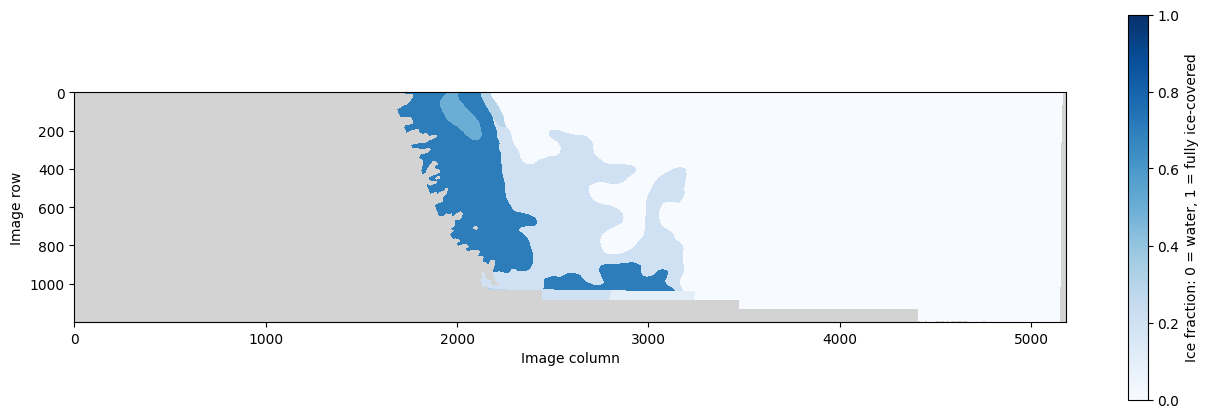

In [37]:
import matplotlib.pyplot as plt

cmap = plt.colormaps["Blues"].copy()
cmap.set_bad("lightgrey")

plt.figure(figsize=(16, 5))
plt.imshow(sic, cmap=cmap, vmin=0, vmax=1, interpolation="nearest")
plt.colorbar(label="Ice fraction: 0 = water, 1 = fully ice-covered")
plt.xlabel("Image column")
plt.ylabel("Image row")
plt.show()

## Setting up the satellite input

In [38]:
with Dataset(path) as nc:
    channel_list = []
    for var_name in nc.variables:
        if var_name.startswith("btemp"):

            channel_data = nc[var_name][:]

            channel_tensor = torch.tensor(channel_data, dtype=torch.float32)

            channel_list.append(channel_tensor)


amsr_14ch = torch.stack(channel_list, dim=0)
print("\nAMSR2 shape:", amsr_14ch.shape)
print(f"Value range (Kelvin): min={amsr_14ch.min():.1f} K, max={amsr_14ch.max():.1f} K")


AMSR2 shape: torch.Size([14, 48, 207])
Value range (Kelvin): min=-2.1 K, max=1.3 K


## Upsampling the satellite data

In [39]:
import torch.nn.functional as F
target_H, target_W = sic.shape
amsr_4d = amsr_14ch.unsqueeze(0)
amsr_upsampled = F.interpolate(
    amsr_4d,
    size=(target_H, target_W),
    mode='bilinear',
    align_corners=False
).squeeze(0)  # Remove batch dim -> [14, 1200, 5185]
print("Original AMSR2 shape: ", amsr_14ch.shape)        # [14, 48, 207]
print("Upsampled AMSR2 shape:", amsr_upsampled.shape)  # [14, 1200, 5185]

Original AMSR2 shape:  torch.Size([14, 48, 207])
Upsampled AMSR2 shape: torch.Size([14, 1200, 5185])


### Adding SAR input

In [40]:
with Dataset(path) as nc:
    # 1. Load the 2 SAR radar channels (in decibels dB)
    sar_primary = torch.tensor(nc["nersc_sar_primary"][:], dtype=torch.float32)
    sar_secondary = torch.tensor(nc["nersc_sar_secondary"][:], dtype=torch.float32)

# Stack the two SAR channels: Shape [2, 1200, 5185]
sar_2ch = torch.stack([sar_primary, sar_secondary], dim=0)

# 2. Bundle SAR (2 channels) + AMSR2 (14 channels) together!
full_inputs = torch.cat([sar_2ch, amsr_upsampled], dim=0)

print("SAR Shape:        ", sar_2ch.shape)          # [2, 1200, 5185]
print("AMSR2 Shape:      ", amsr_upsampled.shape)  # [14, 1200, 5185]
print("Full Input Tensor:", full_inputs.shape)     # [16, 1200, 5185]

SAR Shape:         torch.Size([2, 1200, 5185])
AMSR2 Shape:       torch.Size([14, 1200, 5185])
Full Input Tensor: torch.Size([16, 1200, 5185])


### Divide the images into patches so that it is within GPU mem limit

In [41]:
def patch_batches(X, Y, size=256, batch_size=2):
    """
    X: CPU tensor [channels, H, W].
    Y: masked SIC array [H, W].
    Batches: X [B, channels, size, size], Y [B, 1, size, size].
    """
    H, W = Y.shape
    assert X.shape[-2:] == (H, W)
    assert min(H, W) >= size
    Y = torch.from_numpy(Y.filled(np.nan).copy())[None]
    pairs = []
    for row in range(0, H, size):
        for col in range(0, W, size):
            # Shift edge windows inward; no padding.
            r, c = min(row, H-size), min(col, W-size)
            pairs.append((X[:, r:r+size, c:c+size],
                          Y[:, r:r+size, c:c+size]))
    return torch.utils.data.DataLoader(
        pairs, batch_size=batch_size, shuffle=True)

### Training small snippet

In [42]:
import segmentation_models_pytorch as smp
import torch
import numpy as np
import matplotlib.pyplot as plt

def train_model(model, loader, val_loader=None, epochs=10, lr=1e-4, save_name="best_model.pth"):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    model.cuda()
    best_val_loss = float("inf")
    
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0.0
        num_batches = 0
        
        for x, y in loader:
            x, y = x.cuda(), y.cuda()
            valid = torch.isfinite(y)
            if valid.sum() == 0: continue
            y = torch.nan_to_num(y)

            optimizer.zero_grad(set_to_none=True)
            pred = model(x)
            loss = ((pred[valid] - y[valid]) ** 2).mean()
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
            num_batches += 1
            
        avg_loss = epoch_loss / max(num_batches, 1)
        
        if val_loader is not None:
            model.eval()
            val_loss, v_batches = 0.0, 0
            with torch.no_grad():
                for vx, vy in val_loader:
                    vx, vy = vx.cuda(), vy.cuda()
                    v_valid = torch.isfinite(vy)
                    if v_valid.sum() == 0: continue
                    val_loss += ((model(vx)[v_valid] - torch.nan_to_num(vy)[v_valid]) ** 2).mean().item()
                    v_batches += 1
            avg_val = val_loss / max(v_batches, 1)
            print(f"Epoch {epoch + 1:02d} / {epochs} | Train Loss: {avg_loss:.5f} | Val Loss: {avg_val:.5f}")
            
            if avg_val < best_val_loss:
                best_val_loss = avg_val
                torch.save(model.state_dict(), save_name)
                print(f"  --> Saved new best weights to {save_name} (Val Loss: {best_val_loss:.5f})")
        else:
            print(f"Epoch {epoch + 1:02d} / {epochs} | Train Loss: {avg_loss:.5f}")
    
    return model

def evaluate_and_plot(model, X_full, sic_ground_truth, size=256):
    model.eval()
    H, W = sic_ground_truth.shape
    pred_canvas = torch.zeros((H, W), device="cuda")
    weight_canvas = torch.zeros((H, W), device="cuda")
    
    with torch.no_grad():
        for r_step in range(0, H, size):
            for c_step in range(0, W, size):
                r = min(r_step, H - size)
                c = min(c_step, W - size)
                patch = X_full[:, r : r + size, c : c + size].unsqueeze(0).cuda()
                out = model(patch).squeeze()
                pred_canvas[r : r + size, c : c + size] += out
                weight_canvas[r : r + size, c : c + size] += 1.0

    full_pred = (pred_canvas / weight_canvas).cpu().numpy()
    gt = sic_ground_truth.filled(np.nan) if hasattr(sic_ground_truth, "filled") else np.array(sic_ground_truth)
    valid_mask = np.isfinite(gt)
    
    err = np.abs(full_pred - gt)
    mae = np.nanmean(err)
    rmse = np.sqrt(np.nanmean(err ** 2))
    print(f"--- EVALUATION METRICS ---")
    print(f"MAE: {mae:.4f} | RMSE: {rmse:.4f}")
    
    gt_plot = np.where(valid_mask, gt, np.nan)
    pred_plot = np.where(valid_mask, full_pred, np.nan)
    err_plot = np.where(valid_mask, err, np.nan)
    
    ice_cmap = plt.colormaps["Blues"].copy()
    ice_cmap.set_bad("lightgrey")
    error_cmap = plt.colormaps["Reds"].copy()
    error_cmap.set_bad("lightgrey")
    
    fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(16, 12), sharex=True)
    im0 = axes[0].imshow(gt_plot, cmap=ice_cmap, vmin=0, vmax=1, interpolation="nearest")
    axes[0].set_title("1. Ground Truth Ice Chart (SIC)", fontsize=13)
    axes[0].set_ylabel("Image row")
    plt.colorbar(im0, ax=axes[0], fraction=0.015, pad=0.01, label="Ice Fraction")
    
    im1 = axes[1].imshow(pred_plot, cmap=ice_cmap, vmin=0, vmax=1, interpolation="nearest")
    axes[1].set_title("2. Model Predicted Ice Fraction", fontsize=13)
    axes[1].set_ylabel("Image row")
    plt.colorbar(im1, ax=axes[1], fraction=0.015, pad=0.01, label="Ice Fraction")
    
    im2 = axes[2].imshow(err_plot, cmap=error_cmap, vmin=0, vmax=0.5, interpolation="nearest")
    axes[2].set_title(f"3. Spatial Error |Prediction - GT| (MAE: {mae:.3f}, RMSE: {rmse:.3f})", fontsize=13)
    axes[2].set_xlabel("Image column")
    axes[2].set_ylabel("Image row")
    plt.colorbar(im2, ax=axes[2], fraction=0.015, pad=0.01, label="Absolute Error")
    
    plt.tight_layout()
    plt.show()
    return full_pred, mae, rmse


### Train Model with Validation and Evaluate Best Weights


Epoch 01 / 100 | Train Loss: 0.27789 | Val Loss: 0.09804
  --> Saved new best weights to best_seaice_weights.pth (Val Loss: 0.09804)
Epoch 02 / 100 | Train Loss: 0.12949 | Val Loss: 0.08864
  --> Saved new best weights to best_seaice_weights.pth (Val Loss: 0.08864)
Epoch 03 / 100 | Train Loss: 0.06839 | Val Loss: 0.07624
  --> Saved new best weights to best_seaice_weights.pth (Val Loss: 0.07624)
Epoch 04 / 100 | Train Loss: 0.06084 | Val Loss: 0.06585
  --> Saved new best weights to best_seaice_weights.pth (Val Loss: 0.06585)
Epoch 05 / 100 | Train Loss: 0.04719 | Val Loss: 0.05123
  --> Saved new best weights to best_seaice_weights.pth (Val Loss: 0.05123)
Epoch 06 / 100 | Train Loss: 0.06164 | Val Loss: 0.04751
  --> Saved new best weights to best_seaice_weights.pth (Val Loss: 0.04751)
Epoch 07 / 100 | Train Loss: 0.04279 | Val Loss: 0.05180
Epoch 08 / 100 | Train Loss: 0.02800 | Val Loss: 0.03329
  --> Saved new best weights to best_seaice_weights.pth (Val Loss: 0.03329)
Epoch 09 / 1

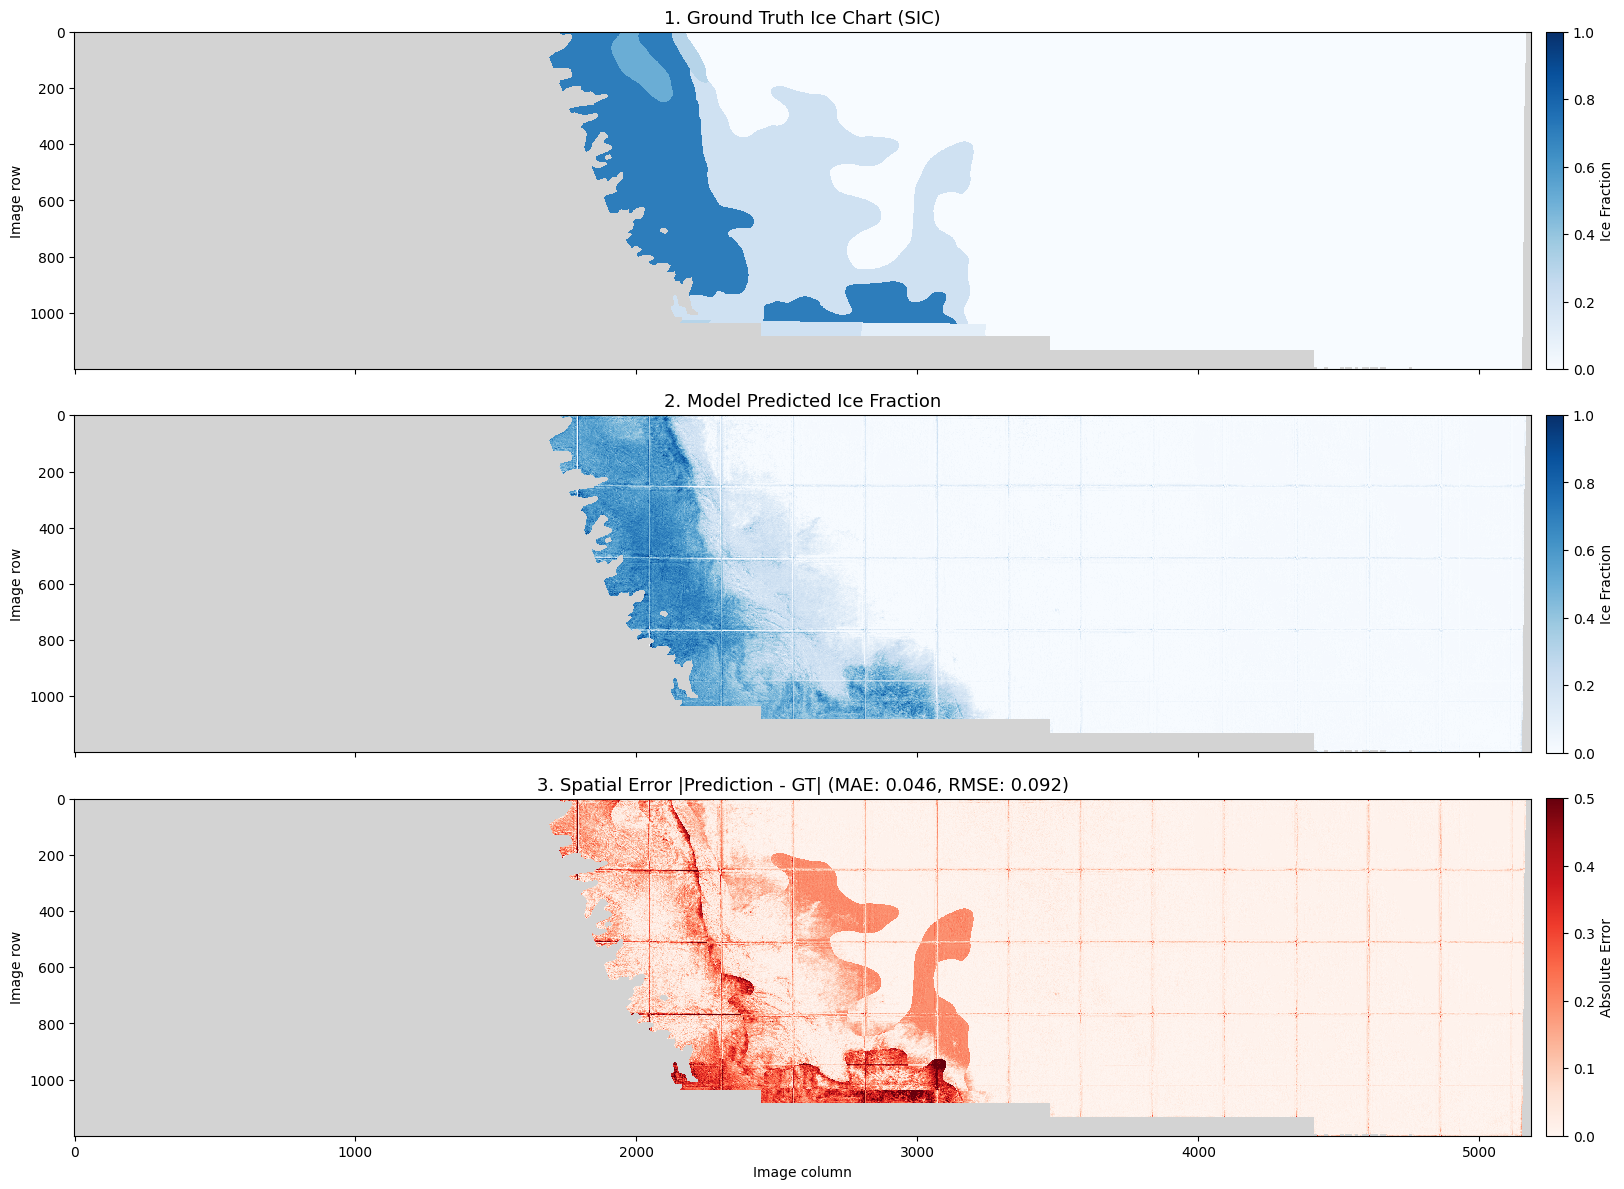

(array([[ 0.30181578,  0.03354228,  0.01484471, ...,  0.05770983,
          0.11221594, -0.14827845],
        [ 0.33629924,  0.03425435, -0.02129604, ...,  0.0924314 ,
          0.31630647, -0.17203654],
        [ 0.30689797, -0.08553872, -0.088585  , ...,  0.17317466,
          0.13199845, -0.24110411],
        ...,
        [-0.204296  , -0.02558112,  0.8312809 , ...,  0.09583421,
          0.23882738, -0.19979693],
        [-0.12723555, -0.38135216,  0.2981853 , ...,  0.165863  ,
          0.27038136, -0.16758749],
        [-0.15255255, -0.12233823,  0.29294842, ...,  0.05719048,
          0.00337755, -0.2154291 ]], shape=(1200, 5185), dtype=float32),
 np.float64(0.046424355606327),
 np.float64(0.09209433472052636))

In [46]:
# 1. Initialize model (e.g. Unet or Segformer)
model = smp.Unet(
    "resnet34", encoder_weights=None, encoder_depth=3,
    decoder_channels=(32, 16, 8), in_channels=16, classes=1
)

# 2. Train with validation and automatically save best weights
loader = patch_batches(full_inputs, sic, size=256, batch_size=32)
trained_model = train_model(model, loader=loader, val_loader=loader, epochs=100, save_name="best_seaice_weights.pth")

# 3. Load the best saved weights and plot
model.load_state_dict(torch.load("weights/best_seaice_weights.pth"))
evaluate_and_plot(model, full_inputs, sic)
